# Elasticsearch Deep Dive : Architecture, Lucene Internals, and Resouce Consumption

## Summary

This notebook is a **self-contained learning resource** for understanding how Elasticsearch works internally during:

- **indexing / ingestion**
- **search / query execution**
- **segment creation and merging**
- **distributed fan-out across shards**
- **query profiling**
- **performance benchmarking**

It is designed for readers who want to go beyond API usage and build an accurate mental model of:

```text
Cluster → Index → Shard → Segment → Terms / Posting Lists
```

---

## What this notebook teaches

By the end of the notebook, the reader should understand:

1. Why **each shard is a Lucene index**
2. How documents move through the **indexing pipeline**
3. Why **refresh** affects search visibility and indexing throughput
4. Why too many **segments** or too many **shards** hurt performance
5. How Elasticsearch executes a query with the **scatter → gather** model
6. Why **filter context** is usually faster than scoring queries
7. How to use the **Profile API** to inspect Lucene execution details

---

## How to read this notebook

Each major step follows the same pattern:

1. **Summary / concept**
2. **Detailed explanation**
3. **Code cell**
4. **What to observe**
5. **Why it matters in production**

This format makes the notebook suitable for:

- conference workshops
- internal engineering training
- self-study
- open-source GitHub documentation

---

## Recommended prerequisites

- Basic understanding of JSON documents
- Basic Elasticsearch query syntax
- Local Elasticsearch running at `http://localhost:9200`
- Python packages:
  - `elasticsearch`
  - `matplotlib`
  - `pandas` (optional but helpful)

---

## Architecture at a glance

```text
Client
  │
  ▼
Coordinator Node
  │
  ├── Shard 0  → Lucene index → segments → posting lists
  ├── Shard 1  → Lucene index → segments → posting lists
  └── Shard 2  → Lucene index → segments → posting lists
```

**Important idea:** Elasticsearch is the distributed layer. Lucene is the search engine core.

# Mental Model — Elasticsearch vs Lucene

Elasticsearch is built on top of **Apache Lucene**.

A useful mental model is:

| Layer | Responsibility |
|---|---|
| Elasticsearch | distributed coordination, shard routing, APIs, replication, cluster management |
| Lucene | indexing structures, segments, posting lists, query execution, scoring |

This means that many “Elasticsearch performance questions” are really about **Lucene behavior inside each shard**.

---

## Core hierarchy

```text
Cluster
  └── Index
        ├── Shard
        │     ├── Segment
        │     ├── Segment
        │     └── Segment
        └── Shard
              ├── Segment
              └── Segment
```

- An **index** is a logical dataset
- A **shard** is a physical partition
- A **segment** is an immutable Lucene index file
- Queries run **inside each shard**
- Elasticsearch merges results **after shard-level execution**

# Section 1 — Setup and Cluster Inspection

## Summary

Before demonstrating indexing and search internals, we first verify that the Elasticsearch cluster is reachable and healthy.

## Why this matters

If cluster state is unhealthy, later results can be misleading. For example:

- missing shards can change query behavior
- unassigned replicas can affect health status
- disconnected nodes can invalidate a distributed demo

## What to observe

Look for:

- cluster status (`green`, `yellow`, `red`)
- number of nodes
- number of primary shards
- whether the cluster is ready for experiments

In [1]:
from elasticsearch import Elasticsearch
import time
import random
import string
from collections import defaultdict

es = Elasticsearch("http://localhost:9200")
es.info()

ObjectApiResponse({'name': '77591fe23a97', 'cluster_name': 'docker-cluster', 'cluster_uuid': 'Xc89dUj7Sjyh8IwxCKFgcw', 'version': {'number': '9.3.0', 'build_flavor': 'default', 'build_type': 'docker', 'build_hash': '17b451d8979a29e31935fe1eb901310350b30e62', 'build_date': '2026-01-29T10:05:46.708397977Z', 'build_snapshot': False, 'lucene_version': '10.3.2', 'minimum_wire_compatibility_version': '8.19.0', 'minimum_index_compatibility_version': '8.0.0'}, 'tagline': 'You Know, for Search'})

# Utility Helpers — DataFrame Output and Query Profiling

The notebook now includes small helper functions that make Elasticsearch responses easier to inspect in Jupyter:

- `hits_to_df(...)` converts search hits into a pandas DataFrame.
- `records_to_df(...)` converts generic lists of dictionaries such as CAT API output into a DataFrame.
- `profile_to_df(...)` flattens the Elasticsearch `profile=true` output so each Lucene query step can be reviewed as tabular data.
- `run_search(...)` runs a search, optionally enables profiling, and returns both the raw response and ready-to-view DataFrames.

This keeps the demo readable while giving you a better way to inspect search results and query execution details.


In [2]:

import pandas as pd

def hits_to_df(response, source_only=True, include_meta=True):
    """Convert Elasticsearch hits into a pandas DataFrame."""
    hits = response.get("hits", {}).get("hits", [])
    rows = []

    for hit in hits:
        row = {}
        if include_meta:
            row["_index"] = hit.get("_index")
            row["_id"] = hit.get("_id")
            row["_score"] = hit.get("_score")

        if source_only:
            row.update(hit.get("_source", {}))
        else:
            row["hit"] = hit

        rows.append(row)

    return pd.DataFrame(rows)


def records_to_df(records):
    """Convert a list of dict records into a pandas DataFrame."""
    return pd.DataFrame(records)


def _flatten_profile_node(node, shard_id, path="root"):
    row = {
        "shard_id": shard_id,
        "path": path,
        "type": node.get("type"),
        "description": node.get("description"),
        "time_in_nanos": node.get("time_in_nanos", 0),
        "time_ms": round(node.get("time_in_nanos", 0) / 1_000_000, 3),
    }

    breakdown = node.get("breakdown", {})
    for key, value in breakdown.items():
        row[f"breakdown.{key}"] = value

    rows = [row]

    for idx, child in enumerate(node.get("children", [])):
        child_path = f"{path}.{idx}"
        rows.extend(_flatten_profile_node(child, shard_id=shard_id, path=child_path))

    return rows


def profile_to_df(response):
    """Flatten Elasticsearch profile output into a pandas DataFrame."""
    shards = response.get("profile", {}).get("shards", [])
    rows = []

    for shard in shards:
        shard_id = shard.get("id")
        for search_block in shard.get("searches", []):
            for idx, node in enumerate(search_block.get("query", [])):
                rows.extend(_flatten_profile_node(node, shard_id=shard_id, path=f"query.{idx}"))

    return pd.DataFrame(rows)


def run_search(index, *, query, size=5, profile=False, sort=None, **kwargs):
    """Run a search and return the raw response plus DataFrames for hits and profiling."""
    response = es.search(
        index=index,
        size=size,
        query=query,
        profile=profile,
        sort=sort,
        **kwargs,
    )

    result = {
        "response": response,
        "hits_df": hits_to_df(response),
    }

    if profile:
        result["profile_df"] = profile_to_df(response)

    return result


### Explanation of the code above

This code creates a Python Elasticsearch client and checks whether the server is reachable.

- `Elasticsearch("http://localhost:9200")` creates the client
- `es.info()` returns cluster and version metadata

### What to observe

In the result, check:

- Elasticsearch version
- cluster name
- basic server information

### Why it matters in production

Always confirm connectivity and version before benchmarking or profiling. Small version differences can change defaults and internal behavior.

In [23]:

cluster_health = es.cluster.health()
cluster_health


ObjectApiResponse({'cluster_name': 'docker-cluster', 'status': 'green', 'timed_out': False, 'number_of_nodes': 1, 'number_of_data_nodes': 1, 'active_primary_shards': 28, 'active_shards': 28, 'relocating_shards': 0, 'initializing_shards': 0, 'unassigned_shards': 0, 'unassigned_primary_shards': 0, 'delayed_unassigned_shards': 0, 'number_of_pending_tasks': 0, 'number_of_in_flight_fetch': 0, 'task_max_waiting_in_queue_millis': 0, 'active_shards_percent_as_number': 100.0})

### Explanation of the code above

This code checks cluster health.

Cluster states:

- `green`: all primary and replica shards allocated
- `yellow`: primary shards allocated, some replicas missing
- `red`: some primary shards missing

### What to observe

Pay attention to:

- `status`
- `number_of_nodes`
- `active_primary_shards`
- `active_shards`

### Why it matters in production

Performance experiments are most useful when the cluster is in a stable state. A red cluster can distort results.

# Section 2 — Create the Demo Index

## Summary

We create a demo index with multiple shards to show how Elasticsearch distributes data and executes distributed search.

## Detailed explanation

Each shard is a separate Lucene index. By creating multiple shards, we make it possible to demonstrate:

- routing during indexing
- distributed fan-out during search
- shard-level profiling
- segment growth inside each shard

## What to observe

After index creation, inspect:

- shard count
- settings
- mapping
- whether the index exists as expected

In [4]:
INDEX_NAME = "demo_index"

if es.indices.exists(index=INDEX_NAME):
    es.indices.delete(index=INDEX_NAME)

es.indices.create(
    index=INDEX_NAME,
    settings={
        "number_of_shards": 3,
        "number_of_replicas": 0,
        "refresh_interval": "1s"
    },
    mappings={
        "properties": {
            "title": {"type": "text"},
            "category": {"type": "keyword"},
            "status": {"type": "keyword"},
            "price": {"type": "float"},
            "is_active": {"type": "boolean"},
            "created_at": {"type": "date"}
        }
    }
)

ObjectApiResponse({'acknowledged': True, 'shards_acknowledged': True, 'index': 'demo_index'})

### Explanation of the code above

This code deletes any previous demo index and creates a new one.

Key settings:

- `number_of_shards = 3` lets us demonstrate fan-out
- `number_of_replicas = 0` keeps the local demo simple
- `refresh_interval = 1s` uses the default near-real-time behavior

The mapping uses both:

- **text fields** for full-text search
- **keyword / boolean / numeric fields** for structured filters and aggregations

### What to observe

Check that the index is created successfully.

### Why it matters in production

Shard count and mapping design strongly affect CPU, memory, indexing throughput, and search latency.

In [5]:

index_details = es.indices.get(index=INDEX_NAME)
index_settings_df = records_to_df([
    {
        "index": name,
        "number_of_shards": details["settings"]["index"].get("number_of_shards"),
        "number_of_replicas": details["settings"]["index"].get("number_of_replicas"),
        "refresh_interval": details["settings"]["index"].get("refresh_interval"),
    }
    for name, details in index_details.items()
])
index_settings_df


,index,number_of_shards,number_of_replicas,refresh_interval
0,demo_index,3,0,1s


### Explanation of the code above

This retrieves index metadata so you can inspect the final settings and mappings actually stored by Elasticsearch.

### What to observe

Verify:

- shard count
- replica count
- refresh interval
- field types

### Why it matters in production

Always verify actual applied settings rather than assuming your request was stored exactly as expected.

# Section 3 — Generate and Ingest Demo Documents

## Summary

Now we create synthetic documents and bulk index them into Elasticsearch.

## Detailed explanation

During indexing, Elasticsearch does several things internally:

1. receives the document
2. determines the target shard using routing
3. analyzes text fields
4. updates the inverted index
5. writes data into new Lucene segments
6. makes data searchable after refresh

## What to observe

After indexing, observe:

- document count
- index size
- segment growth
- search visibility after refresh

In [6]:
WORDS = [
    "apple", "banana", "car", "database", "elasticsearch", "lucene",
    "search", "distributed", "segment", "query", "filter", "score",
    "index", "cluster", "node", "refresh", "merge", "cache"
]
CATEGORIES = ["tech", "fruit", "transport", "infra"]
STATUSES = ["active", "draft", "archived"]

def rand_text(n=8):
    return " ".join(random.choice(WORDS) for _ in range(n))

def make_docs(n=3000):
    docs = []
    now_ms = int(time.time() * 1000)
    for i in range(n):
        docs.append({
            "_index": INDEX_NAME,
            "_id": str(i),
            "_source": {
                "title": rand_text(random.randint(5, 12)),
                "category": random.choice(CATEGORIES),
                "status": random.choice(STATUSES),
                "price": round(random.uniform(10, 500), 2),
                "is_active": random.choice([True, False]),
                "created_at": now_ms - random.randint(0, 7 * 24 * 3600 * 1000)
            }
        })
    return docs

docs = make_docs(3000)
len(docs), docs[0]

docs = make_docs(3000)
records_to_df([docs[0]["_source"]]).assign(_id=docs[0]["_id"])


,title,category,status,price,is_active,created_at,_id
0,merge distributed refresh car banana distribut...,tech,active,248.46,True,1772907691892,0


### Explanation of the code above

This code generates synthetic documents with both **text** and **structured** fields.

Why both types are useful:

- `title` supports full-text search
- `category`, `status`, and `is_active` support filters
- `price` supports numeric use cases
- `created_at` supports time-based scenarios

### What to observe

Inspect one example document and notice how it is suitable for both:

- full-text queries
- structured Boolean filters

### Why it matters in production

Real-world performance depends heavily on field design. Structured fields and full-text fields behave very differently internally.

In [7]:

from elasticsearch.helpers import bulk

bulk(es, docs)
es.indices.refresh(index=INDEX_NAME)
records_to_df([es.count(index=INDEX_NAME)])


,0,1
0,count,_shards


### Explanation of the code above

This code bulk-indexes documents and then forces a refresh.

- `bulk(...)` sends many documents efficiently
- `refresh(...)` makes newly indexed documents searchable
- `count(...)` confirms the expected number of indexed documents

### What to observe

Confirm that the document count matches the generated dataset size.

### Why it matters in production

Bulk ingestion is the normal production pattern. Refresh frequency strongly affects how fast indexing can run.

# Section 4 — Refresh, Search Visibility, and Near-Real-Time Behavior

## Summary

Elasticsearch is **near-real-time**, not fully real-time.

## Detailed explanation

When a document is indexed, it is not always immediately visible to search. A refresh makes newly indexed data searchable by opening a new searcher on recent segments.

Useful distinction:

| Operation | What it does |
|---|---|
| refresh | makes recent indexed data searchable |
| flush | commits data more durably and clears translog state |
| merge | combines smaller segments into larger segments |

## What to observe

Try indexing documents and searching before/after refresh to understand visibility.

In [8]:

# Index one document without forcing immediate refresh
es.index(
    index=INDEX_NAME,
    id="visibility-demo",
    document={
        "title": "refresh visibility elasticsearch lucene segment demo",
        "category": "tech",
        "status": "active",
        "price": 99.0,
        "is_active": True,
        "created_at": int(time.time() * 1000)
    },
    refresh=False
)

before_refresh_resp = run_search(
    INDEX_NAME,
    query={"match": {"title": "visibility"}},
    size=5,
    profile=True,
)
before_refresh_total = before_refresh_resp["response"]["hits"]["total"]

es.indices.refresh(index=INDEX_NAME)

after_refresh_resp = run_search(
    INDEX_NAME,
    query={"match": {"title": "visibility"}},
    size=5,
    profile=True,
)
after_refresh_total = after_refresh_resp["response"]["hits"]["total"]

visibility_summary_df = records_to_df([
    {"step": "before refresh", "hits_total": before_refresh_total["value"], "relation": before_refresh_total["relation"]},
    {"step": "after refresh", "hits_total": after_refresh_total["value"], "relation": after_refresh_total["relation"]},
])
visibility_summary_df


,step,hits_total,relation
0,before refresh,0,eq
1,after refresh,1,eq


### Explanation of the code above

This code intentionally demonstrates search visibility before and after refresh.

- First, a document is indexed with `refresh=False`
- Then a search is executed
- After that, a manual refresh is triggered
- The same search is executed again

### What to observe

You may see the document become visible **only after refresh**.

### Why it matters in production

This is the reason Elasticsearch is called near-real-time. Lower refresh intervals improve visibility but usually reduce indexing throughput.

# Section 5 — Inspect Lucene Segments

## Summary

Segments are the core storage units inside each shard.

## Detailed explanation

Lucene segments are immutable. New indexing activity creates more segments over time. If there are too many small segments, search becomes more expensive because Lucene must check more structures.

Elasticsearch periodically merges segments to reduce this overhead.

## What to observe

Inspect:

- segment count
- which shard each segment belongs to
- segment sizes
- whether many small segments are accumulating

In [9]:

segments = es.cat.segments(index=INDEX_NAME, format="json")
segments_df = records_to_df(segments)
segments_df.head()


,index,shard,prirep,ip,segment,generation,docs.count,docs.deleted,size,size.memory,committed,searchable,version,compound
0,demo_index,0,p,172.21.0.2,_0,0,990,0,101.5kb,0,false,true,10.3.2,true
1,demo_index,0,p,172.21.0.2,_1,1,1,0,6kb,0,false,true,10.3.2,true
2,demo_index,1,p,172.21.0.2,_0,0,1043,0,106.4kb,0,false,true,10.3.2,true
3,demo_index,2,p,172.21.0.2,_0,0,967,0,100.2kb,0,false,true,10.3.2,true


### Explanation of the code above

This retrieves low-level segment information for the index.

Each row represents one Lucene segment and usually includes fields such as:

- shard number
- segment name
- document count
- deleted document count
- size

### What to observe

Look for:

- multiple segments per shard
- uneven segment sizes
- deleted docs if updates/deletes occurred

### Why it matters in production

High segment counts can increase CPU usage, file handle usage, and query latency.

In [10]:

# Simple segment summary by shard
segment_summary = defaultdict(lambda: {"segments": 0, "docs": 0, "deleted_docs": 0})

for row in segments:
    shard = row["shard"]
    segment_summary[shard]["segments"] += 1
    segment_summary[shard]["docs"] += int(row.get("docs.count", 0))
    segment_summary[shard]["deleted_docs"] += int(row.get("docs.deleted", 0))

segment_summary_df = (
    records_to_df(
        [{"shard": shard, **values} for shard, values in segment_summary.items()]
    )
    .sort_values("shard")
    .reset_index(drop=True)
)
segment_summary_df


,shard,segments,docs,deleted_docs
0,0,2,991,0
1,1,1,1043,0
2,2,1,967,0


### Explanation of the code above

This code summarizes segment information by shard so the reader can see the distribution more clearly.

### What to observe

Compare shards and ask:

- Do all shards have a similar number of segments?
- Are document counts roughly balanced?
- Are deleted docs accumulating?

### Why it matters in production

Balanced shards usually lead to more predictable performance. Skewed data distribution can create hotspot shards.

# Section 6 — Distributed Search and Scatter → Gather

## Summary

When a query runs, Elasticsearch distributes it to relevant shards and later merges the results.

## Detailed explanation

Search execution typically follows this pattern:

```text
Client
  │
  ▼
Coordinator Node
  │
  ├── search shard 0
  ├── search shard 1
  └── search shard 2
        ↓
     top-K per shard
        ↓
   global merge and ranking
```

## What to observe

Use profiling and normal search results to connect the distributed model with actual execution output.

In [11]:

search_result = run_search(
    INDEX_NAME,
    size=5,
    profile=True,
    query={
        "match": {
            "title": "elasticsearch segment query"
        }
    }
)

search_hits_df = search_result["hits_df"]
search_profile_df = search_result["profile_df"]

search_hits_df.head()


,_index,_id,_score,title,category,status,price,is_active,created_at
0,demo_index,2913,4.191559,elasticsearch elasticsearch query query segmen...,fruit,active,471.09,False,1772957158170
1,demo_index,101,3.959935,query segment score elasticsearch query,tech,active,488.54,True,1772948437686
2,demo_index,2004,3.800486,score segment elasticsearch elasticsearch segm...,infra,active,67.52,False,1772726307293
3,demo_index,1787,3.789193,segment segment segment elasticsearch refresh ...,transport,active,287.17,False,1772465879249
4,demo_index,838,3.770476,query apple segment query elasticsearch search,fruit,active,482.35,False,1772990562947


### Explanation of the code above

This runs a normal full-text search against the `title` field.

Internally, the query is executed separately in each shard, and the coordinator merges the top shard-level results.

### What to observe

Inspect the hit list and note that the response looks simple, even though the execution underneath is distributed.

### Why it matters in production

A simple user-facing query can still trigger significant shard-level work and coordination overhead.

# Section 7 — Boolean Queries, Filter Context, and Bitset-Friendly Patterns

## Summary

Many Elasticsearch queries are internally rewritten into Lucene BooleanQuery trees.

## Detailed explanation

Common Boolean parts:

- `must` → required and scored
- `should` → optional / score-influencing
- `filter` → required but not scored
- `must_not` → exclusion

Filters are important because they usually avoid scoring and are often much faster for structured conditions.

## What to observe

Use profiling to see how Boolean structure appears in the execution tree.

In [12]:

bool_query_result = run_search(
    INDEX_NAME,
    size=5,
    profile=True,
    query={
        "bool": {
            "must": [
                {"match": {"title": "elasticsearch query"}}
            ],
            "filter": [
                {"term": {"status": "active"}},
                {"term": {"is_active": True}}
            ]
        }
    }
)

bool_hits_df = bool_query_result["hits_df"]
bool_profile_df = bool_query_result["profile_df"]

bool_hits_df.head()


,_index,_id,_score,title,category,status,price,is_active,created_at
0,demo_index,101,2.760613,query segment score elasticsearch query,tech,active,488.54,True,1772948437686
1,demo_index,242,2.564808,filter query segment apple elasticsearch query,transport,active,165.90,True,1772500805831
2,demo_index,1211,2.523211,elasticsearch elasticsearch refresh score quer...,transport,active,384.00,True,1772926601896
3,demo_index,482,2.487636,database query query filter filter elasticsearch,fruit,active,63.06,True,1772709831853
4,demo_index,737,2.436685,query merge score query segment cache elastics...,transport,active,21.76,True,1772489470780


### Explanation of the code above

This query mixes:

- full-text matching in `must`
- exact filtering in `filter`

This is a very common and efficient real-world pattern.

### What to observe

Notice that the response includes scored full-text matches, but only for documents that first pass the structured filters.

### Why it matters in production

Separating scoring logic from structured filters is one of the easiest ways to improve search efficiency.

In [13]:

profile_result = run_search(
    INDEX_NAME,
    size=3,
    profile=True,
    query={
        "bool": {
            "must": [
                {"match": {"title": "elasticsearch segment"}}
            ],
            "filter": [
                {"term": {"status": "active"}}
            ]
        }
    }
)

profile_hits_df = profile_result["hits_df"]
profile_steps_df = profile_result["profile_df"].sort_values(
    ["shard_id", "time_in_nanos"],
    ascending=[True, False]
).reset_index(drop=True)

profile_steps_df[["shard_id", "path", "type", "description", "time_ms"]].head(20)


,shard_id,path,type,description,time_ms
0,[pSOL20g7QDy5W6pTtaWqqA][demo_index][0],query.0,BooleanQuery,(#status:active title:elasticsearch title:segm...,0.637
1,[pSOL20g7QDy5W6pTtaWqqA][demo_index][0],query.0.1,TermQuery,title:elasticsearch,0.109
2,[pSOL20g7QDy5W6pTtaWqqA][demo_index][0],query.0.0,TermQuery,status:active,0.084
3,[pSOL20g7QDy5W6pTtaWqqA][demo_index][0],query.0.2,TermQuery,title:segment,0.063
4,[pSOL20g7QDy5W6pTtaWqqA][demo_index][1],query.0,BooleanQuery,(#status:active title:elasticsearch title:segm...,0.573
5,[pSOL20g7QDy5W6pTtaWqqA][demo_index][1],query.0.0,TermQuery,status:active,0.078
6,[pSOL20g7QDy5W6pTtaWqqA][demo_index][1],query.0.1,TermQuery,title:elasticsearch,0.056
7,[pSOL20g7QDy5W6pTtaWqqA][demo_index][1],query.0.2,TermQuery,title:segment,0.046
8,[pSOL20g7QDy5W6pTtaWqqA][demo_index][2],query.0,BooleanQuery,(#status:active title:elasticsearch title:segm...,0.539
9,[pSOL20g7QDy5W6pTtaWqqA][demo_index][2],query.0.1,TermQuery,title:elasticsearch,0.075


### Explanation of the code above

This enables the **Profile API** for a Boolean query.

The profile output exposes Lucene-level execution details, including rewritten query structures and timing.

### What to observe

Depending on the query and Lucene rewrite behavior, you may see structures such as:

- `BooleanQuery`
- `BoostQuery`
- term-level query nodes

### Why it matters in production

Profiling is essential when you need to answer questions such as:

- Why is this query slow?
- Which clause costs the most CPU?
- Did the query rewrite into something unexpected?

# Section 8 — Filter vs Scoring Query Benchmark

## Summary

Now we compare a scoring query with a mostly filter-based query.

## Detailed explanation

The goal is not to produce a perfect scientific benchmark, but to build intuition about why filters are often cheaper.

## What to observe

Compare average response times across repeated runs.

In [14]:

def timed_search(body, runs=20, index_name=INDEX_NAME):
    times = []
    for _ in range(runs):
        t0 = time.perf_counter()
        es.search(index=index_name, **body)
        times.append(time.perf_counter() - t0)
    return {
        "runs": runs,
        "avg_ms": sum(times) / len(times) * 1000,
        "min_ms": min(times) * 1000,
        "max_ms": max(times) * 1000,
        "all_ms": [t * 1000 for t in times],
    }

scoring_body = {
    "size": 10,
    "query": {
        "match": {"title": "elasticsearch query segment refresh"}
    }
}

filter_body = {
    "size": 10,
    "query": {
        "bool": {
            "filter": [
                {"term": {"status": "active"}},
                {"term": {"is_active": True}}
            ]
        }
    }
}

scoring_stats = timed_search(scoring_body, runs=20)
filter_stats = timed_search(filter_body, runs=20)

benchmark_df = records_to_df([
    {"query_type": "scoring query", **{k: v for k, v in scoring_stats.items() if k != "all_ms"}},
    {"query_type": "filter query", **{k: v for k, v in filter_stats.items() if k != "all_ms"}},
])

scoring_profile_df = run_search(INDEX_NAME, profile=True, **scoring_body)["profile_df"]
filter_profile_df = run_search(INDEX_NAME, profile=True, **filter_body)["profile_df"]

benchmark_df


,query_type,runs,avg_ms,min_ms,max_ms
0,scoring query,20,4.486257,3.728333,8.027398
1,filter query,20,4.384485,3.665303,5.164477


### Explanation of the code above

This repeats two search patterns multiple times:

- a **scoring full-text query**
- a **filter-only query**

The average response time is then compared.

### What to observe

Filter-only queries are often faster, though exact results depend on hardware, data distribution, caches, and Elasticsearch version.

### Why it matters in production

Whenever you do not need scoring, prefer filter context for structured fields.

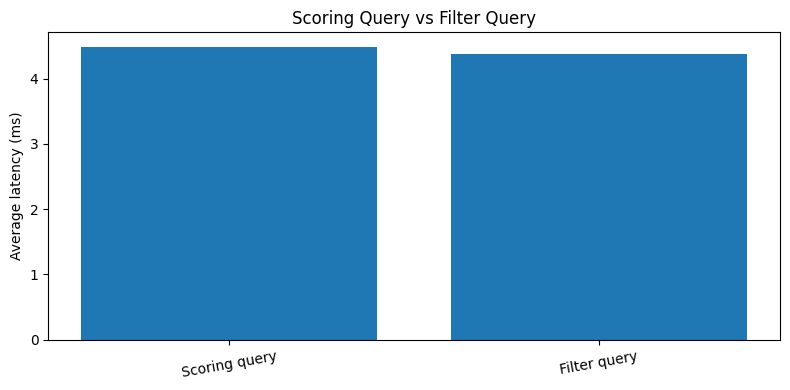

In [15]:
import matplotlib.pyplot as plt

labels = ["Scoring query", "Filter query"]
avg_values = [scoring_stats["avg_ms"], filter_stats["avg_ms"]]

plt.figure(figsize=(8, 4))
plt.bar(labels, avg_values)
plt.ylabel("Average latency (ms)")
plt.title("Scoring Query vs Filter Query")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

### Explanation of the code above

This chart visualizes the average latency of the two query styles.

### What to observe

The visual gap helps reinforce the idea that scoring work often costs more CPU than simple filtering.

### Why it matters in production

Charts make performance trade-offs easier to communicate to teams during architecture discussions.

# Section 9 — Refresh Interval Benchmark

## Summary

Refresh frequency affects the trade-off between search visibility and indexing throughput.

## Detailed explanation

A shorter refresh interval makes data searchable sooner, but opens new searchers more frequently, which can reduce indexing throughput.

A common ingestion optimization is:

1. set `refresh_interval = -1`
2. bulk ingest data
3. restore a normal refresh interval
4. manually refresh

## What to observe

Compare indexing speed under different refresh settings.

In [16]:
def recreate_benchmark_index(name, refresh_interval):
    if es.indices.exists(index=name):
        es.indices.delete(index=name)
    es.indices.create(
        index=name,
        settings={
            "number_of_shards": 1,
            "number_of_replicas": 0,
            "refresh_interval": refresh_interval
        },
        mappings={
            "properties": {
                "title": {"type": "text"},
                "status": {"type": "keyword"},
                "is_active": {"type": "boolean"}
            }
        }
    )

def benchmark_bulk_index(index_name, n_docs=4000):
    bench_docs = []
    for i in range(n_docs):
        bench_docs.append({
            "_index": index_name,
            "_id": str(i),
            "_source": {
                "title": rand_text(8),
                "status": random.choice(STATUSES),
                "is_active": random.choice([True, False]),
            }
        })
    t0 = time.perf_counter()
    bulk(es, bench_docs)
    es.indices.refresh(index=index_name)
    return (time.perf_counter() - t0) * 1000

refresh_results = {}

for refresh_value in ["1s", "-1"]:
    idx = f"bench_refresh_{refresh_value.replace('-', 'off').replace('s', 'sec')}"
    recreate_benchmark_index(idx, refresh_value)
    refresh_results[refresh_value] = benchmark_bulk_index(idx, n_docs=4000)

refresh_results

refresh_results_df = records_to_df(
    [{"refresh_interval": key, "bulk_index_time_ms": value} for key, value in refresh_results.items()]
)
refresh_results_df


,refresh_interval,bulk_index_time_ms
0,1s,133.446404
1,-1,126.984524


### Explanation of the code above

This benchmark creates fresh indices with different refresh settings and measures bulk indexing time.

### What to observe

In many environments, indexing with `refresh_interval = -1` is faster.

### Why it matters in production

For batch ingestion or backfills, disabling refresh temporarily is a common optimization.

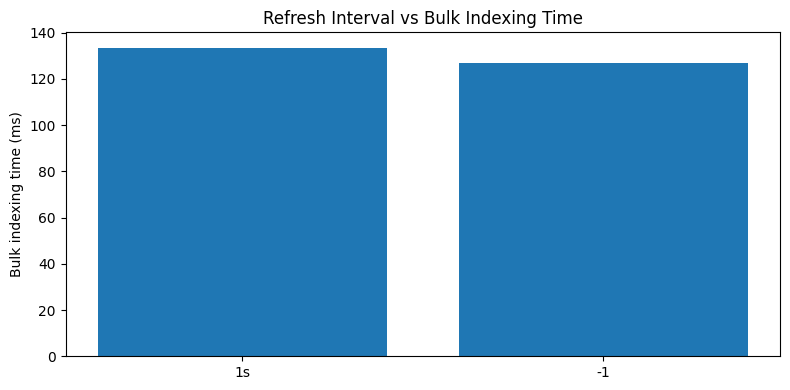

In [17]:
labels = list(refresh_results.keys())
values = list(refresh_results.values())

plt.figure(figsize=(8, 4))
plt.bar(labels, values)
plt.ylabel("Bulk indexing time (ms)")
plt.title("Refresh Interval vs Bulk Indexing Time")
plt.tight_layout()
plt.show()

### Explanation of the code above

This chart compares the indexing time under different refresh settings.

### What to observe

A lower indexing time means higher throughput.

### Why it matters in production

This is one of the most practical Elasticsearch tuning levers for ingestion-heavy workloads.

# Section 10 — Shard Count Benchmark

## Summary

More shards do not automatically mean faster search.

## Detailed explanation

Each shard has overhead:

- memory structures
- file handles
- thread scheduling
- query fan-out coordination

For small or moderate datasets, too many shards often makes performance worse.

## What to observe

Compare average query latency for the same dataset stored with different shard counts.

In [18]:
def recreate_shard_benchmark_index(name, shards):
    if es.indices.exists(index=name):
        es.indices.delete(index=name)
    es.indices.create(
        index=name,
        settings={
            "number_of_shards": shards,
            "number_of_replicas": 0,
            "refresh_interval": "-1"
        },
        mappings={
            "properties": {
                "title": {"type": "text"},
                "status": {"type": "keyword"},
                "is_active": {"type": "boolean"}
            }
        }
    )

def load_same_dataset(index_name, n_docs=5000):
    data = []
    for i in range(n_docs):
        data.append({
            "_index": index_name,
            "_id": str(i),
            "_source": {
                "title": rand_text(8),
                "status": random.choice(STATUSES),
                "is_active": random.choice([True, False]),
            }
        })
    bulk(es, data)
    es.indices.refresh(index=index_name)

def average_query_latency(index_name, runs=20):
    times = []
    body = {
        "size": 10,
        "query": {
            "match": {"title": "elasticsearch distributed segment"}
        }
    }
    for _ in range(runs):
        t0 = time.perf_counter()
        es.search(index=index_name, **body)
        times.append(time.perf_counter() - t0)
    return sum(times) / len(times) * 1000

shard_benchmark = {}

for shard_count in [1, 3, 8]:
    idx = f"bench_shards_{shard_count}"
    recreate_shard_benchmark_index(idx, shard_count)
    load_same_dataset(idx, n_docs=5000)
    shard_benchmark[shard_count] = average_query_latency(idx, runs=20)

shard_benchmark

shard_benchmark_df = records_to_df(
    [{"shard_count": key, "avg_search_latency_ms": value} for key, value in shard_benchmark.items()]
)
shard_benchmark_df


,shard_count,avg_search_latency_ms
0,1,2.528847
1,3,3.164655
2,8,2.350654


### Explanation of the code above

This benchmark creates several indices that differ only in shard count, loads similar data, and measures average query latency.

### What to observe

For a dataset of this size, a higher shard count may not help and may even increase latency.

### Why it matters in production

Oversharding is one of the most common Elasticsearch design mistakes.

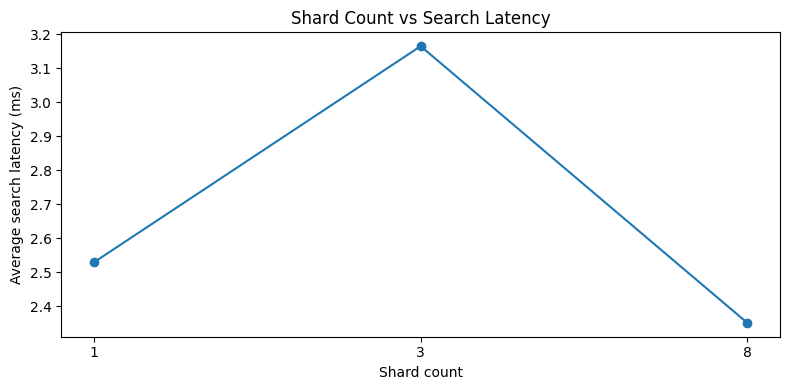

In [19]:
labels = [str(k) for k in shard_benchmark.keys()]
values = list(shard_benchmark.values())

plt.figure(figsize=(8, 4))
plt.plot(labels, values, marker="o")
plt.ylabel("Average search latency (ms)")
plt.xlabel("Shard count")
plt.title("Shard Count vs Search Latency")
plt.tight_layout()
plt.show()

### Explanation of the code above

This line chart shows how query latency changes as shard count changes.

### What to observe

The key lesson is not the exact number, but the **trend**.

### Why it matters in production

Shard count should be chosen based on dataset size, node count, recovery needs, and expected workload — not by guesswork.

# Section 11 — Segment Growth Timeline

## Summary

This experiment visualizes how segments accumulate during repeated small indexing batches.

## Detailed explanation

Frequent small indexing + refresh cycles tend to create many small segments. That is useful for teaching because it makes segment growth visible.

## What to observe

Watch segment count increase across steps.

In [20]:
timeline_index = "bench_segment_timeline"

if es.indices.exists(index=timeline_index):
    es.indices.delete(index=timeline_index)

es.indices.create(
    index=timeline_index,
    settings={
        "number_of_shards": 1,
        "number_of_replicas": 0,
        "refresh_interval": "-1"
    },
    mappings={
        "properties": {
            "title": {"type": "text"},
            "status": {"type": "keyword"}
        }
    }
)

segment_timeline = []

for batch_no in range(1, 11):
    batch_docs = []
    for i in range(200):
        batch_docs.append({
            "_index": timeline_index,
            "_id": f"{batch_no}-{i}",
            "_source": {
                "title": rand_text(8),
                "status": random.choice(STATUSES)
            }
        })
    bulk(es, batch_docs)
    es.indices.refresh(index=timeline_index)
    segs = es.cat.segments(index=timeline_index, format="json")
    segment_timeline.append({
        "batch": batch_no,
        "segment_count": len(segs),
        "doc_count": sum(int(s.get("docs.count", 0)) for s in segs)
    })

segment_timeline

segment_timeline_df = records_to_df(segment_timeline)
segment_timeline_df


,batch,segment_count,doc_count
0,1,1,200
1,2,2,400
2,3,3,600
3,4,4,800
4,5,5,1000
5,6,6,1200
6,7,7,1400
7,8,8,1600
8,9,9,1800
9,10,10,2000


### Explanation of the code above

This repeatedly indexes small batches, refreshes, and records the current segment count.

### What to observe

As batches increase, segment count usually grows.

### Why it matters in production

Small frequent writes can create many small segments, which increases search overhead until merge catches up.

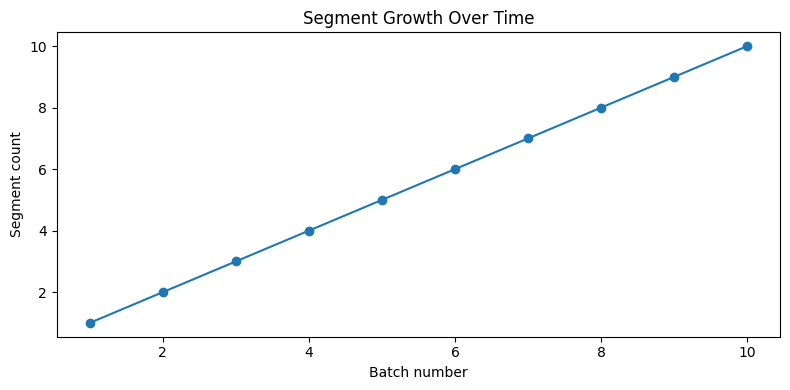

In [21]:
batches = [x["batch"] for x in segment_timeline]
segment_counts = [x["segment_count"] for x in segment_timeline]

plt.figure(figsize=(8, 4))
plt.plot(batches, segment_counts, marker="o")
plt.xlabel("Batch number")
plt.ylabel("Segment count")
plt.title("Segment Growth Over Time")
plt.tight_layout()
plt.show()

### Explanation of the code above

This chart visualizes segment accumulation over time.

### What to observe

The shape of the line tells you whether segment growth is steady, bursty, or flattening.

### Why it matters in production

Segment growth directly influences query overhead and merge pressure.

# Section 12 — Optional Force Merge Demonstration

## Summary

Force merge is a maintenance operation that reduces segment count by merging segments.

## Important caution

Force merge is **not** something you should run casually on hot, actively written indices.

It is usually more appropriate for:

- read-mostly indices
- historical archives
- controlled maintenance windows

## What to observe

Compare segment count before and after a force merge.

In [22]:

before_merge_segments = len(es.cat.segments(index=timeline_index, format="json"))

es.indices.forcemerge(index=timeline_index, max_num_segments=1)

after_merge_segments = len(es.cat.segments(index=timeline_index, format="json"))

records_to_df([
    {
        "before_merge_segments": before_merge_segments,
        "after_merge_segments": after_merge_segments,
    }
])


,before_merge_segments,after_merge_segments
0,10,1


### Explanation of the code above

This code force-merges the timeline index down toward one segment.

### What to observe

The number of segments should decrease.

### Why it matters in production

This demonstrates the concept of reducing segment overhead, but should be used carefully in real clusters.

# Section 13 — Final Takeaways

## Operational lessons

From the experiments in this notebook, the most important lessons are:

1. **Refresh is about search visibility**, not the same thing as merge or flush
2. **Each shard is a Lucene index**, so more shards mean more query coordination
3. **Segments matter** because too many of them increase search overhead
4. **Filter context is often cheaper** than scoring queries
5. **Profile API is essential** when investigating slow searches
6. **Disabling refresh temporarily** can improve batch indexing throughput
7. **Oversharding is expensive** and should be avoided

## Suggested follow-up exercises

- Add replicas and compare search behavior
- Compare `term` vs `match` on different field types
- Add updates and deletes to observe `docs.deleted`
- Benchmark phrase queries vs term queries
- Compare sort-heavy queries against relevance-heavy queries